In [ ]:
import dill
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from particles.kalman import Kalman
import particles.state_space_models as ssms

from particles_cdssm.core import CDSSM_SMC, SMC
import particles_cdssm.plot as splt
import particles_cdssm.feynman_kac as sfk
from particles_cdssm.continuous_discrete_ssms import NormalCDSSM, MvNormalCDSSM
import particles_cdssm.auxiliary_bridges as axb

In [ ]:
savefigs = False

- In run id 100, model `mv_ou`, we have some results for $T=1000$, $N_{FFBS}=4000$ and $N_{genealogy}=10000$ that look okay for the Bootstrap PF
These results exclude Part 3, which involves CD-SSM algorithms 
- In run id 50, model `mv_ou`, we have some results for $T=1000$, $N_{FFBS}=400$ and $N_{genealogy}=1000$ that look okay for CD-SSM algorithms

In [3]:
run_id = '20'
cdssm_str = 'mv_ou'

# fks = ['Bootstrap']
# fks = ['GuidedPF']
# fks = ['BootstrapDA', 'BsR_DH']
# fks = ['BootstrapDA', 'BsR_DH']
# fks = ['BwG_DH_DBrP', 'BwR_DH_DBrP']
# fks = ['FwG_OUP', 'FwR_DH_OUP']
fks = ['BootstrapDA', 'BwR_DH_DBrP']


df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

In [4]:
# Work with copies of the original dfs
df_1 = df_part_1.copy()
df_2 = df_part_2.copy()
df_3 = df_part_3.copy()
# df_2 = df_2[df_2['fk'].isin(fks)]

# Extract the metadata
cdssm = metadata['cdssm']
lgssm = metadata['lgssm']
x = metadata['x']
y = metadata['y']
T = len(y)
obs_times = metadata['stored_obs_times']
nruns = metadata['nruns']
N_genealogy = metadata['N_genealogy']
N_FFBS_MCMC = metadata['N_FFBS_MCMC']

ext = '' if cdssm.islgssm else '_pf'

print(f'Model: {cdssm_str}, T: {T}, N_genealogy: {N_genealogy}, N_FFBS_MCMC: {N_FFBS_MCMC}')

print(f'Model params: {cdssm.params}')

Model: mv_ou, T: 100, N_genealogy: 100, N_FFBS_MCMC: 100
Model params: {'rho': array([[1., 1.]]), 'mu': array([[0., 0.]]), 'phi': array([[1., 0.],
       [0., 1.]]), 'G': array([[1., 0.],
       [0., 1.]]), 'covY': array([[0.04, 0.  ],
       [0.  , 0.04]])}


For running a benchmark for testing `CDSSM_SMC` smoothing algorithms: 

- At `N=1000`, we observe MAEs for `FFBS_MCMC` of around 0.01 (see runid 30) using the GuidedPF.
- At `N=10000`, we observe MAEs for `FFBS_MCMC` of around 0.0004. (see runid 20) using the GuidedPF.
So, we might 

# Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

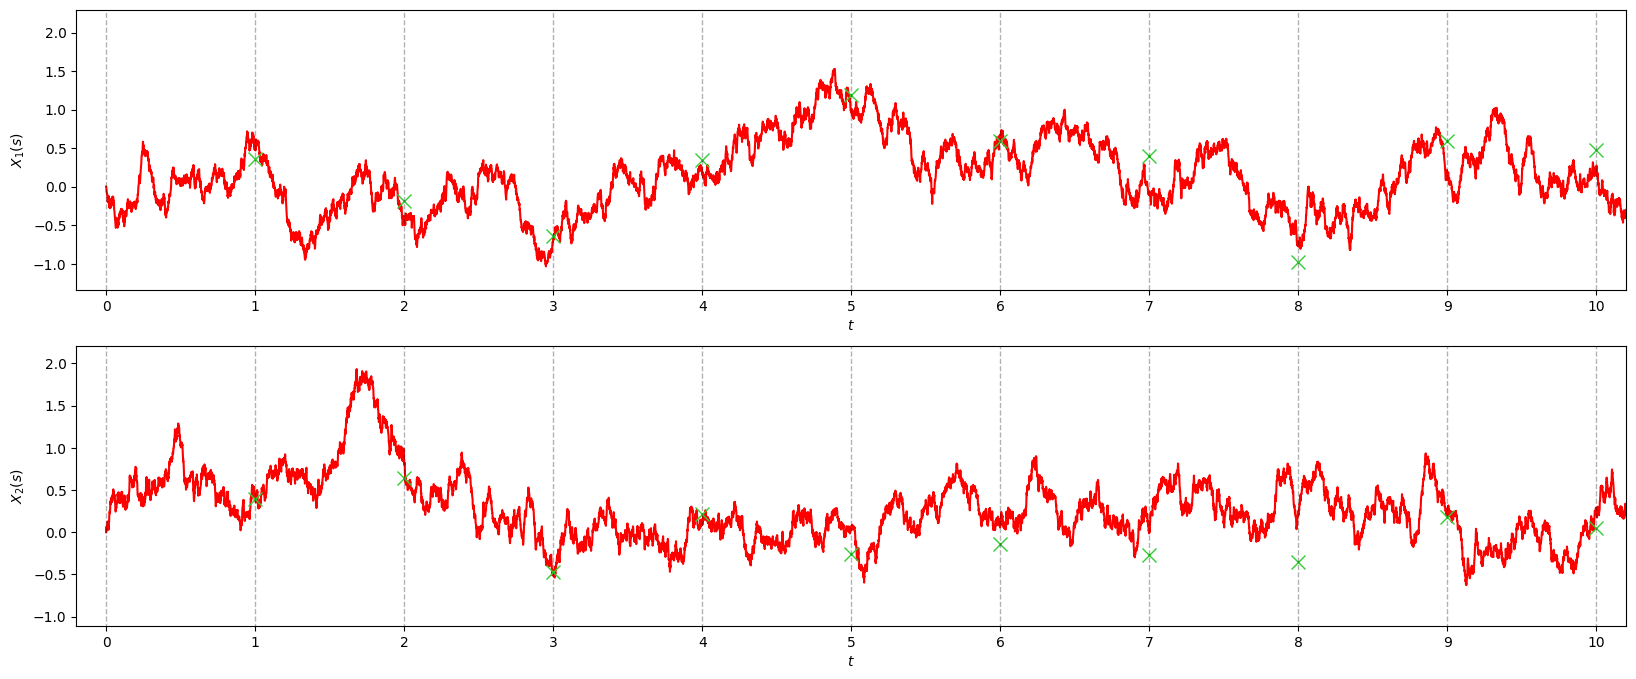

In [5]:
plot_T = 10

x_plt = x[:plot_T + 2]
y_plt = y[:plot_T + 2]

#quantiles = metadata['quantiles']

if isinstance(cdssm, NormalCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x_plt, y_plt)
elif isinstance(cdssm, MvNormalCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x_plt, y_plt)
else:
    pass

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()

# Can add custom changes to the fig/axes below:

# The true target distributions

## Plot of the true Smoothing Distributions

We plot for each of the stored observations times, the filtering distribution vs the smoothing distribution.

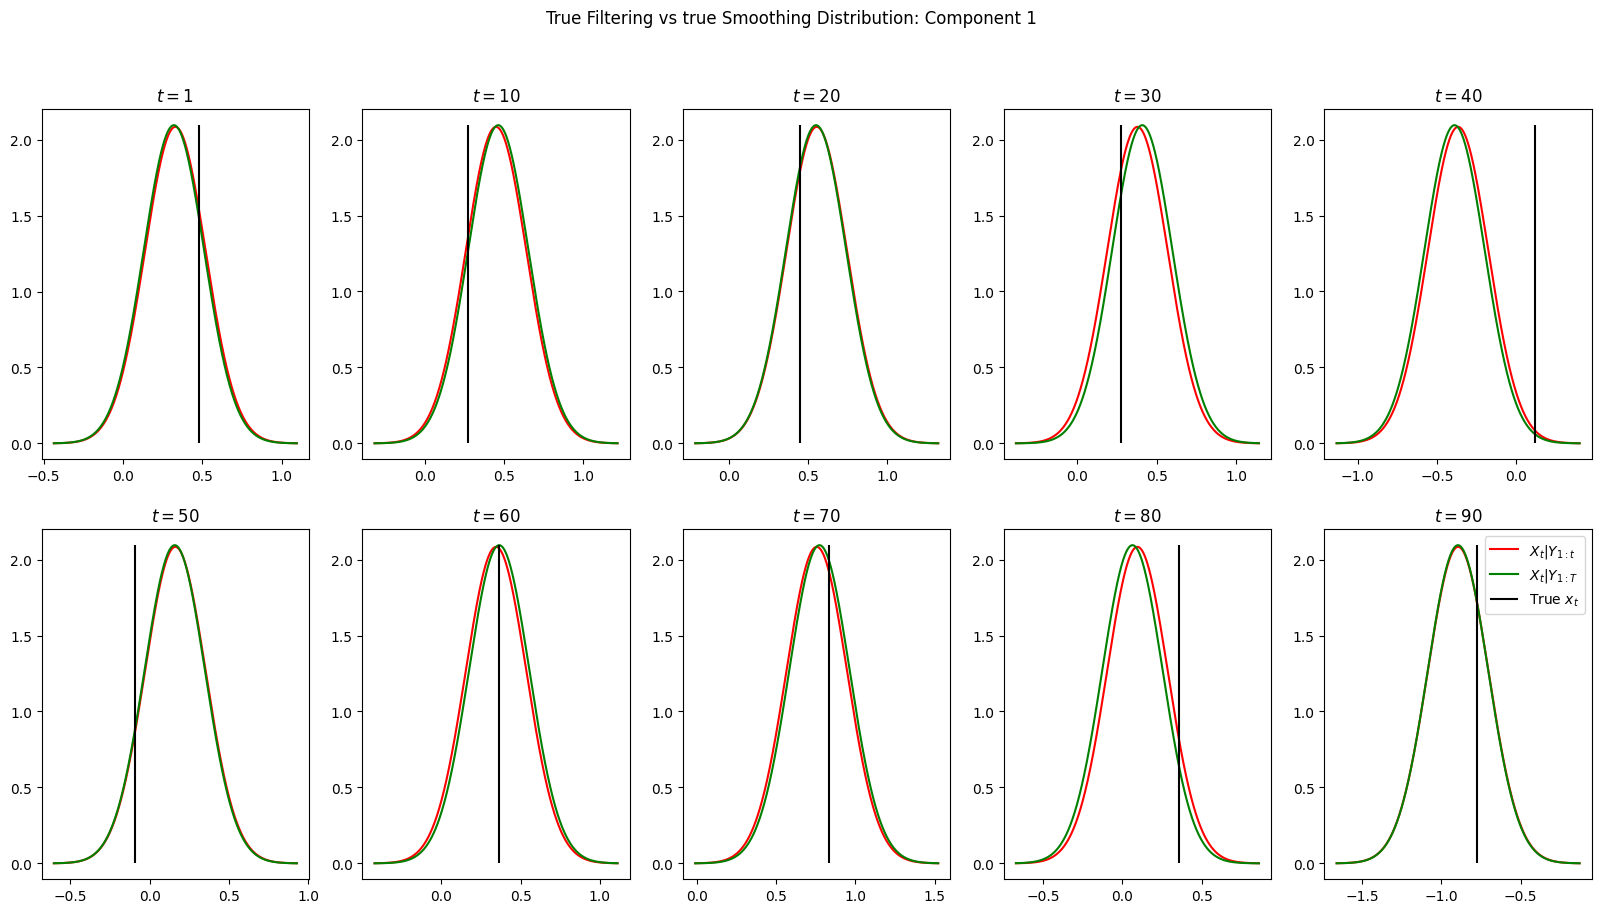

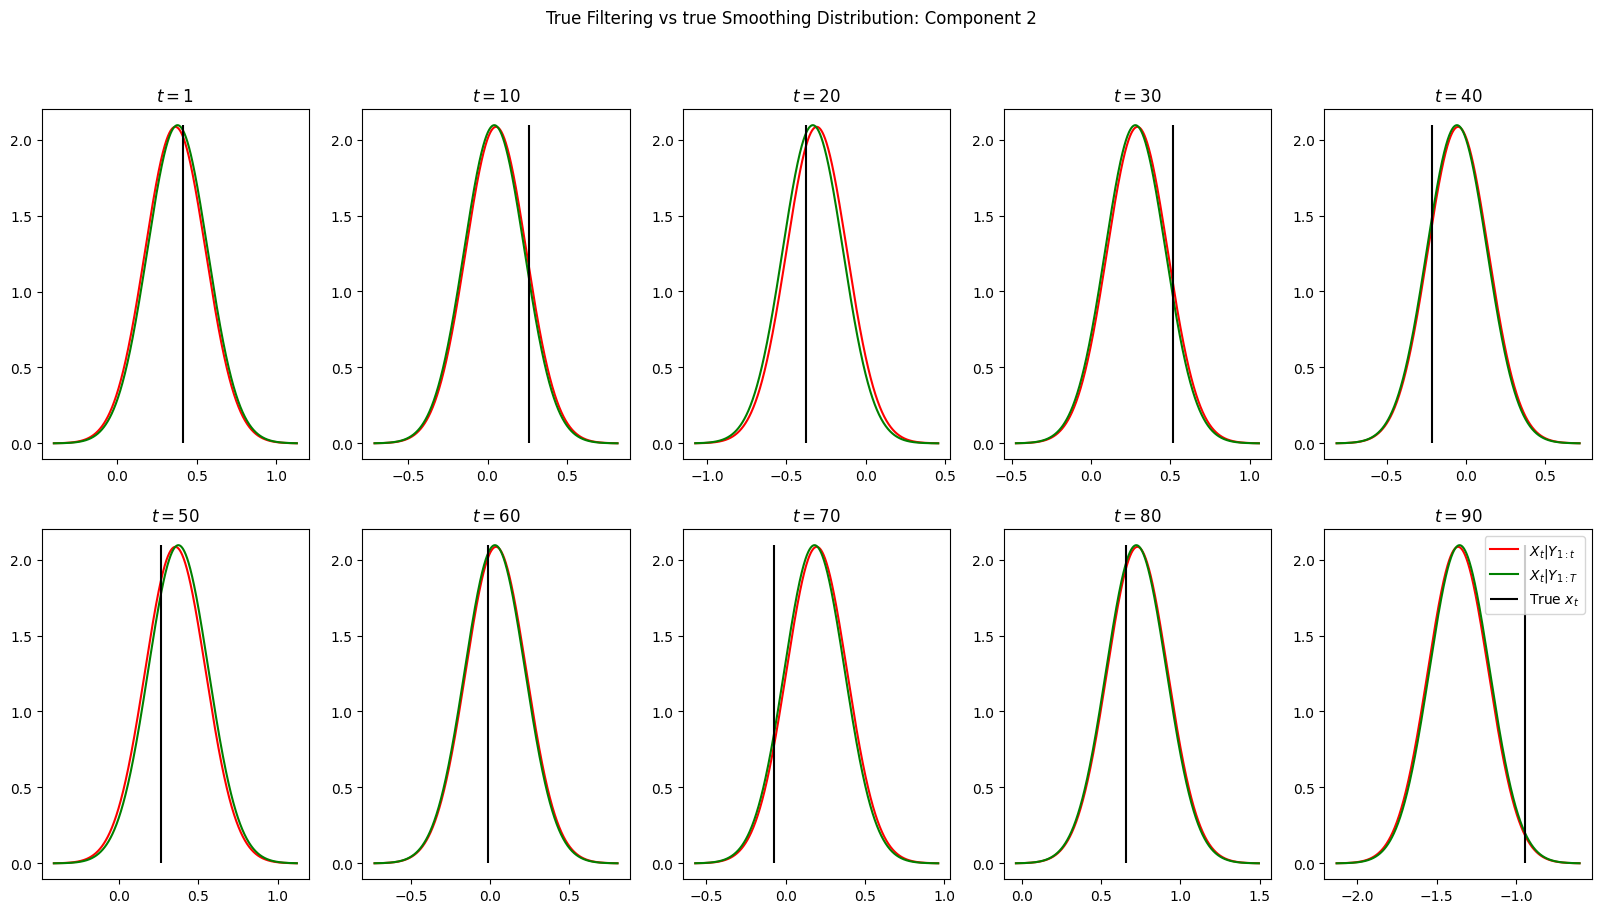

In [6]:
for j in range(1, cdssm.dimX +1):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.ravel()

    for k, ax in enumerate(axes):
        t = obs_times[k]
        x_t_true = x[t][x[t].dtype.names[-1]].ravel()

        x_lim_lower = df_1.loc[t, f'x_t_filt_mean_{j}{ext}'] - 4. * df_1.loc[t, f'x_t_filt_std_{j}{ext}']
        x_lim_upper = df_1.loc[t, f'x_t_filt_mean_{j}{ext}'] + 4. * df_1.loc[t, f'x_t_filt_std_{j}{ext}']

        x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

        filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=df_1.loc[t, f'x_t_filt_mean_{j}{ext}'], scale=df_1.loc[t, f'x_t_filt_std_{j}{ext}'])
        smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=df_1.loc[t, f'x_t_smth_mean_{j}{ext}'], scale=df_1.loc[t, f'x_t_smth_std_{j}{ext}'])
        y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

        ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', label=r'$X_t|Y_{1:t}$')
        ax.plot(x_linsp, smth_pdf_linsp, '-', c='green', label=r'$X_t|Y_{1:T}$')

        ax.vlines(x_t_true[j-1], ymin=0.0, ymax=y_max, colors='black', label=r'True $x_t$')
        ax.set_title(f'$t={t+1}$')
    plt.legend()
    plt.suptitle(f'True Filtering vs true Smoothing Distribution: Component {j}')
    plt.show()
    # plt.legend()
    # plt.show()

# Plot for the paper: involves runs for multiple CD-SSMs: Single Plot

In [7]:
# Selected columns of interest to plot the results:
cols = ['method', 'fk', 'cpu'] + [f'x_{i}_est_1' for i in [0] + list(range(9, 100, 10))] + [f'x_{i}_est_2' for i in [0] + list(range(9, 100, 10))]
# df_1 = df_1[['x_t_smth_mean_1'] + ['x_t_smth_mean_2']]
df_2 = df_2[cols]
df_3 = df_3[cols]

In [8]:
true_vals_df = df_1
results_df = pd.concat([df_2, df_3], axis=0)
# true_vals_df = true_vals_df.set_index('t')

obs_times = df_1.index.to_list()

for t in obs_times:
    results_df[f'x_{t}_est_1_abs_err'] = np.abs(results_df[f'x_{t}_est_1'] - true_vals_df.loc[t, f'x_t_smth_mean_1'])
    results_df[f'x_{t}_est_2_abs_err'] = np.abs(results_df[f'x_{t}_est_2'] - true_vals_df.loc[t, f'x_t_smth_mean_2'])

abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
cpu_df = results_df[['fk'] + ['cpu']].copy()

mae_df = abs_err_df.groupby('fk').mean()
mae_std_df = abs_err_df.groupby('fk').std()
mae_count_df = abs_err_df.groupby('fk').count()
mae_conf_int_df = stats.norm.ppf(0.975) * mae_std_df / np.sqrt(mae_count_df)

Text(0.5, 1.0, '$\\sigma_y=0.2$')

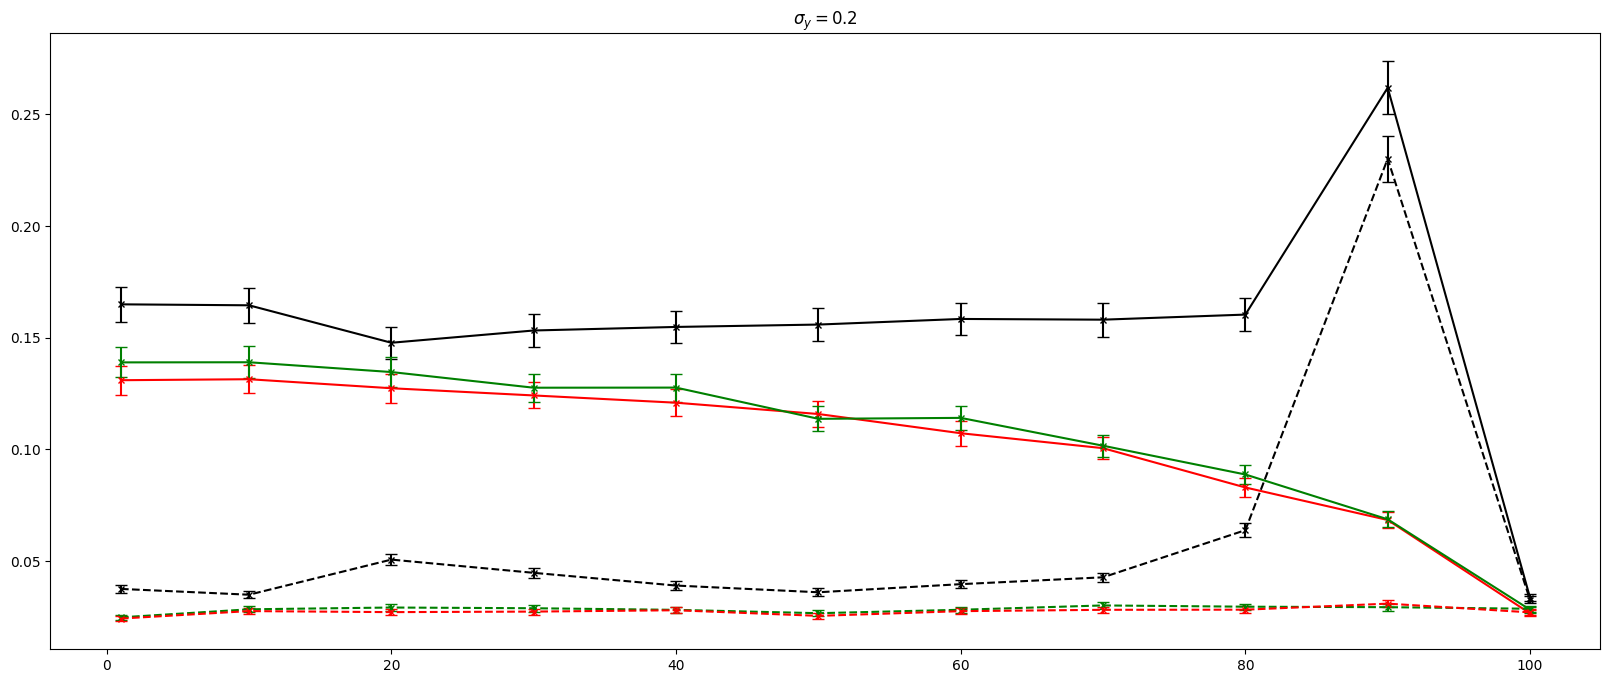

In [9]:
method_map = {'BootstrapDA': 'Bootstrap-GT', 'BwG_NDBr_OUP': 'Backward-GT', 'FwG_NDBrP': 'Forward-GT', 'BsR_DH': 'Bootstrap-FFBS', 'FwR_DH_NDBrP': 'Forward-FFBS', 'BwR_NDBr_OUP': 'Backward-FFBS'} 
color_map = {'BootstrapDA': 'black', 'BwG_NDBr_OUP': 'red', 'FwG_NDBrP': 'green', 'BsR_DH': 'black', 'FwR_DH_NDBrP': 'green', 'BwR_NDBr_OUP': 'red'}
fmt_map = {'BootstrapDA': 'x-', 'BwG_NDBr_OUP': 'x-', 'FwG_NDBrP': 'x-', 'BsR_DH': 'x--', 'FwR_DH_NDBrP': 'x--', 'BwR_NDBr_OUP': 'x--'}

titles = [r'$\sigma_y=0.05$', r'$\sigma_y=0.1$', r'$\sigma_y=0.2$', r'$\sigma_y=0.5$', r'$\sigma_y=1.0$']
lag=0
plot_obs_times = np.array(obs_times[lag:]) + 1
y_label = r'MAE: $\log (\hat{p}(y_{1:t}))$'

# plot_df_genealogy = plot_df[plot_df['method'] == 'genealogy']
# plot_§df_ffbs = plot_df[plot_df['method'] == 'FFBS_MCMC']
fig, ax = plt.subplots(1, 1, figsize=(20, 8), sharey=False)
component = 1
# for j, mae_df, mae_conf_int_df in zip(range(5), mv_ou_mae_dfs, mv_ou_mae_conf_int_dfs):

plot_mae_df  = mae_df[[c for c in mae_df.columns if f'_est_{component}' in c]]
plot_mae_conf_int_df  = mae_conf_int_df[[c for c in mae_df.columns if f'_est_{component}' in c]]

for method in method_map.keys():
    mae = plot_mae_df.loc[method].to_numpy()[lag:]
    mae_err = plot_mae_conf_int_df.loc[method].to_numpy()[lag:]
    ax.errorbar(plot_obs_times, mae, yerr=mae_err, fmt=fmt_map[method], label=method_map[method], markersize=5, capsize=4, color=color_map[method])
# ax.plot(plot_obs_times, mae_df.loc['GuidedPF'].to_numpy()[lag:], '--', label='guided', c='grey', linewidth=1.5)
ax.set_title(titles[j])
# ax.set_yscale('log')

# method_map = {'BootstrapDA': 'Bootstrap', 'BwG_NDBr_OUP': 'Backward'} 
# color_map = {'BootstrapDA': 'black', 'BwG_NDBr_OUP': 'red', 'GuidedPF': 'grey'}
# titles = [r'$\sigma_y=0.05$', r'$\sigma_y=0.1$', r'$\sigma_y=0.2$', r'$\sigma_y=0.5$', r'$\sigma_y=1.0$']
# lag=1
# plot_obs_times = np.array(obs_times[lag:]) + 1

# i=1
# for j, mae_df, mae_conf_int_df in zip(range(5), iou_mae_dfs, iou_mae_conf_int_dfs):
#     for method in method_map.keys():
#         mae = mae_df.loc[method].to_numpy()[lag:]
#         mae_err = mae_conf_int_df.loc[method].to_numpy()[lag:]
#         ax[i, j].errorbar(plot_obs_times, mae, yerr=mae_err, fmt='x-', label=method_map[method], markersize=5, capsize=4, color=color_map[method])
#     ax[i, j].plot(plot_obs_times, mae_df.loc['GuidedPF'].to_numpy()[lag:], '--', label='guided', c='grey', linewidth=1.5)
#     ax[i, j].set_yscale('log')
    
# # Make some final tweaks to the plot:
# ax[0, 0].legend(bbox_to_anchor=(0.49, 0.16))
# ax[0, 0].set_ylabel(y_label + '- Elliptic')
# ax[1, 0].legend(bbox_to_anchor=(0.49, 0.66))
# # ax[1, 0].legend()
# ax[1, 0].set_ylabel(y_label + '- Hypoelliptic')

# for j in range(5):
#     ax[1, j].set_xlabel(r'$t$')
# plt.show()

#     # plt.savefig(f'../poster/results_small.pdf', bbox_inches='tight')
# # plt.show()

Plot for the paper: involves multiple CD-SSMs:

In [10]:
run_ids = ['5', '10', '20', '50', '100']
cdssm_str = 'mv_ou'

dfs_part_1 , dfs_part_2, dfs_part_3, metas = [], [], [], []

for run_id in run_ids:
    df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
    df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
    df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

    dfs_part_1.append(df_part_1)
    dfs_part_2.append(df_part_2)
    dfs_part_3.append(df_part_3)

    with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
        metadata = dill.load(f)
    metas.append(metadata)

# Concatenate the dataframes
dfs_1 = [df.copy() for df in dfs_part_1]
dfs_2 = [df.copy() for df in dfs_part_2]
dfs_3 = [df.copy() for df in dfs_part_3]

mv_ou_mae_dfs = []; mv_ou_mae_std_dfs = []; mv_ou_mae_count_dfs = []; mv_ou_mae_conf_int_dfs = []

obs_times = dfs_1[0].index.tolist()

# Selected columns of interest to plot the results:
cols = ['method', 'fk', 'cpu'] + [f'x_{i}_est_1' for i in [0] + list(range(9, 100, 10))] + [f'x_{i}_est_2' for i in [0] + list(range(9, 100, 10))]

abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
cpu_df = results_df[['fk'] + ['cpu']].copy()

for df_1, df_2, df_3 in zip(dfs_1, dfs_2, dfs_3):

    df_2 = df_2[cols]
    df_3 = df_3[cols]
    
    true_vals_df = df_1
    results_df = pd.concat([df_2, df_3], axis=0)

    for t in obs_times:
        results_df[f'x_{t}_est_1_abs_err'] = np.abs(results_df[f'x_{t}_est_1'] - true_vals_df.loc[t, f'x_t_smth_mean_1'])
        results_df[f'x_{t}_est_2_abs_err'] = np.abs(results_df[f'x_{t}_est_2'] - true_vals_df.loc[t, f'x_t_smth_mean_2'])

    abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
    cpu_df = results_df[['fk'] + ['cpu']].copy()

    mae_df = abs_err_df.groupby('fk').mean()
    mae_std_df = abs_err_df.groupby('fk').std()
    mae_count_df = abs_err_df.groupby('fk').count()
    mae_conf_int_df = stats.norm.ppf(0.975) * mae_std_df / np.sqrt(mae_count_df)

    mv_ou_mae_dfs.append(mae_df)
    mv_ou_mae_std_dfs.append(mae_std_df)
    mv_ou_mae_count_dfs.append(mae_count_df)
    mv_ou_mae_conf_int_dfs.append(mae_conf_int_df)

In [11]:
run_ids = ['5', '10', '20', '50', '100']
cdssm_str = 'iou'

dfs_part_1 , dfs_part_2, dfs_part_3, metas = [], [], [], []

for run_id in run_ids:
    df_part_1 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_1.json')
    df_part_2 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_2.json')
    df_part_3 = pd.read_json(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_part_3.json')

    dfs_part_1.append(df_part_1)
    dfs_part_2.append(df_part_2)
    dfs_part_3.append(df_part_3)

    with open(f'./results/smoothing_exp_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
        metadata = dill.load(f)
    metas.append(metadata)

# Concatenate the dataframes
dfs_1 = [df.copy() for df in dfs_part_1]
dfs_2 = [df.copy() for df in dfs_part_2]
dfs_3 = [df.copy() for df in dfs_part_3]

iou_mae_dfs = []; iou_mae_std_dfs = []; iou_mae_count_dfs = []; iou_mae_conf_int_dfs = []

obs_times = dfs_1[0].index.tolist()

# Selected columns of interest to plot the results:
cols = ['method', 'fk', 'cpu'] + [f'x_{i}_est_1' for i in [0] + list(range(9, 100, 10))] + [f'x_{i}_est_2' for i in [0] + list(range(9, 100, 10))]

abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
cpu_df = results_df[['fk'] + ['cpu']].copy()

for df_1, df_2, df_3 in zip(dfs_1, dfs_2, dfs_3):

    df_2 = df_2[cols]
    df_3 = df_3[cols]
    
    true_vals_df = df_1
    results_df = pd.concat([df_2, df_3], axis=0)

    for t in obs_times:
        results_df[f'x_{t}_est_1_abs_err'] = np.abs(results_df[f'x_{t}_est_1'] - true_vals_df.loc[t, f'x_t_smth_mean_1'])
        results_df[f'x_{t}_est_2_abs_err'] = np.abs(results_df[f'x_{t}_est_2'] - true_vals_df.loc[t, f'x_t_smth_mean_2'])

    abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
    cpu_df = results_df[['fk'] + ['cpu']].copy()

    mae_df = abs_err_df.groupby('fk').mean()
    mae_std_df = abs_err_df.groupby('fk').std()
    mae_count_df = abs_err_df.groupby('fk').count()
    mae_conf_int_df = stats.norm.ppf(0.975) * mae_std_df / np.sqrt(mae_count_df)

    iou_mae_dfs.append(mae_df)
    iou_mae_std_dfs.append(mae_std_df)
    iou_mae_count_dfs.append(mae_count_df)
    iou_mae_conf_int_dfs.append(mae_conf_int_df)

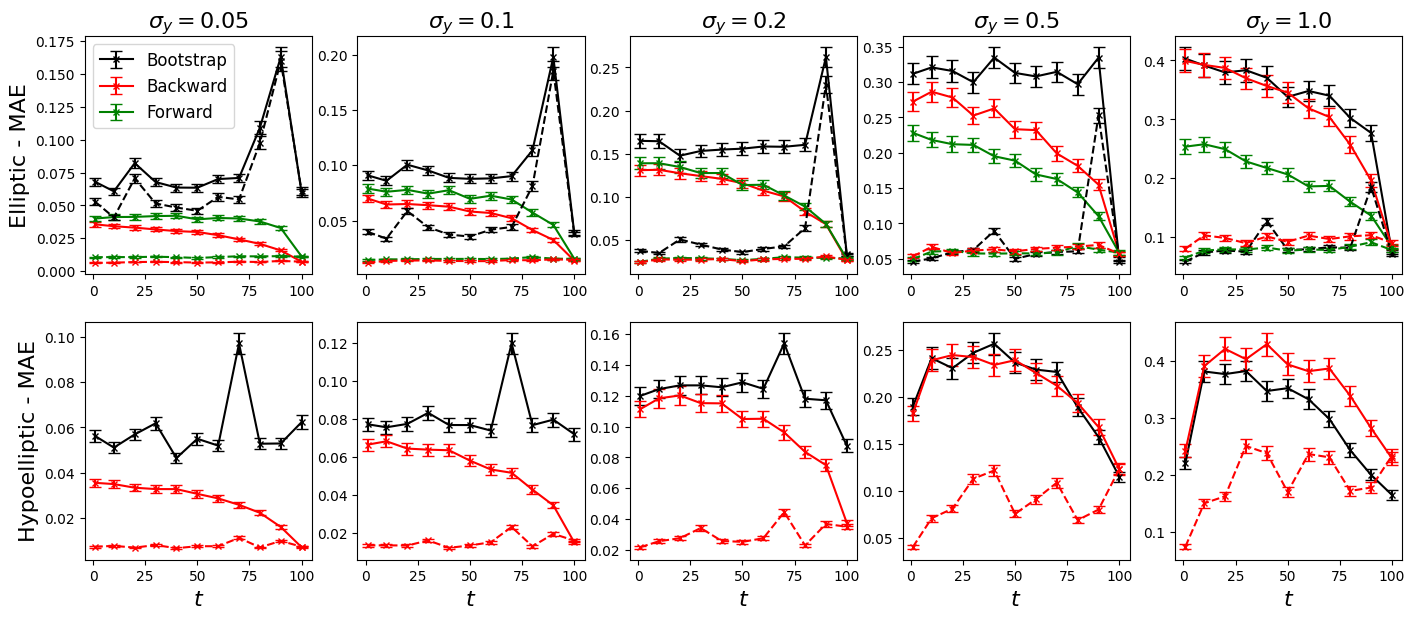

In [12]:
method_map = {'BootstrapDA': 'Bootstrap', 'BwG_NDBr_OUP': 'Backward', 'FwG_NDBrP': 'Forward', 'BsR_DH': None, 'FwR_DH_NDBrP': None, 'BwR_NDBr_OUP': None} 
color_map = {'BootstrapDA': 'black', 'BwG_NDBr_OUP': 'red', 'FwG_NDBrP': 'green', 'BsR_DH': 'black', 'FwR_DH_NDBrP': 'green', 'BwR_NDBr_OUP': 'red'}
fmt_map = {'BootstrapDA': 'x-', 'BwG_NDBr_OUP': 'x-', 'FwG_NDBrP': 'x-', 'BsR_DH': 'x--', 'FwR_DH_NDBrP': 'x--', 'BwR_NDBr_OUP': 'x--'}

titles = [r'$\sigma_y=0.05$', r'$\sigma_y=0.1$', r'$\sigma_y=0.2$', r'$\sigma_y=0.5$', r'$\sigma_y=1.0$']
lag=0
plot_obs_times = np.array(obs_times[lag:]) + 1
y_label = r'MAE: est of $E[X(s_t)| Y_{1:T}=y_{1:T}]$'

a = 17.; b = 8/20 * a
# plot_df_genealogy = plot_df[plot_df['method'] == 'genealogy']
# plot_§df_ffbs = plot_df[plot_df['method'] == 'FFBS_MCMC']
fig, ax = plt.subplots(2, 5, figsize=(a, b), sharey=False)
component = 1
for j, mae_df, mae_conf_int_df in zip(range(5), mv_ou_mae_dfs, mv_ou_mae_conf_int_dfs):
    plot_mae_df = mae_df[[c for c in mae_df.columns if f'_est_{component}' in c]]
    plot_mae_conf_int_df = mae_conf_int_df[[c for c in mae_df.columns if f'_est_{component}' in c]]

    for method in method_map.keys():
        mae = plot_mae_df.loc[method].to_numpy()[lag:]
        mae_err = plot_mae_conf_int_df.loc[method].to_numpy()[lag:]
        ax[0, j].errorbar(plot_obs_times, mae, yerr=mae_err, fmt=fmt_map[method], label=method_map[method], markersize=5, capsize=4, color=color_map[method])
# ax.plot(plot_obs_times, mae_df.loc['GuidedPF'].to_numpy()[lag:], '--', label='guided', c='grey', linewidth=1.5)
        ax[0, j].set_title(titles[j], fontsize=16)
# ax.set_yscale('log')

method_map = {'BootstrapDA': 'Bootstrap', 'BwG_NDBr_OUP': 'Backward', 'BwR_NDBr_OUP': None} 

i=1
for j, mae_df, mae_conf_int_df in zip(range(5), iou_mae_dfs, iou_mae_conf_int_dfs):
    plot_mae_df = mae_df[[c for c in mae_df.columns if f'_est_{component}' in c]]
    plot_mae_conf_int_df = mae_conf_int_df[[c for c in mae_df.columns if f'_est_{component}' in c]]

    for method in method_map.keys():
        mae = plot_mae_df.loc[method].to_numpy()[lag:]
        mae_err = plot_mae_conf_int_df.loc[method].to_numpy()[lag:]
        ax[i, j].errorbar(plot_obs_times, mae, yerr=mae_err, fmt=fmt_map[method], label=method_map[method], markersize=5, capsize=4, color=color_map[method])
#     ax[i, j].plot(plot_obs_times, mae_df.loc['GuidedPF'].to_numpy()[lag:], '--', label='guided', c='grey', linewidth=1.5)
#     ax[i, j].set_yscale('log')

# # Make some final tweaks to the plot:
ax[0, 0].legend(loc='upper left', fontsize=12) #bbox_to_anchor=(0.5, 0.7)
ax[0, 0].set_ylabel('Elliptic - MAE', fontsize=16)
# ax[1, 0].legend(bbox_to_anchor=(0.5, 0.78))
ax[1, 0].set_ylabel('Hypoelliptic - MAE', fontsize=16)

for j in range(5):
    ax[1, j].set_xlabel(r'$t$', fontsize=16)

if savefigs:
    plt.savefig(f'fig_4_smoothing_results.pdf', bbox_inches='tight')
plt.show()
# plt.show()